In [43]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from langdetect import detect, DetectorFactory
import pandas as pd
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import re
from wordcloud import WordCloud
import numpy as np

## 1. Import data.

Make sure all the files are in the working directory.

In [5]:
csv_paths = list(Path("../Dataset/data_old_approach/").glob("*.csv"))

print("CSV files found:")
for p in csv_paths:
    print(p.name)

CSV files found:
bank_of_america__combined_us.csv
chase__combined_us.csv
citi__combined_us.csv
marcus_by_goldman_sachs__combined_us.csv
wells_fargo__combined_us.csv


In [6]:
# import files
raw = pd.concat(
    [
        pd.read_csv(p, dtype=str).assign(source_file=p.name)
        for p in csv_paths
    ],
    ignore_index=True
)

## 2. Data Overview

In [7]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5450 entries, 0 to 5449
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   platform       5450 non-null   object
 1   storefront     5450 non-null   object
 2   app_id         2450 non-null   object
 3   review_id      5450 non-null   object
 4   date           5450 non-null   object
 5   user           5450 non-null   object
 6   rating         5450 non-null   object
 7   title          2450 non-null   object
 8   review         5450 non-null   object
 9   version        2450 non-null   object
 10  package        3000 non-null   object
 11  thumbsUpCount  3000 non-null   object
 12  appVersion     2717 non-null   object
 13  source_file    5450 non-null   object
dtypes: object(14)
memory usage: 596.2+ KB


In [8]:
raw.describe(include = "all")

,platform,storefront,app_id,review_id,date,user,rating,title,review,version,package,thumbsUpCount,appVersion,source_file
count,5450,5450,2450,5450,5450,5450,5450,2450,5450,2450,3000,3000,2717,5450
unique,2,1,5,5450,5449,5404,5,2058,4929,55,5,29,93,5
top,google_play,us,284847138.0,13566342702,2025-12-17 16:42:21,A Google user,5,Easy to use,good,25.10.04,com.infonow.bofa,0.0,9.90.0,bank_of_america__combined_us.csv
freq,3000,5450,490,1,2,16,3032,17,47,268,600,2623,508,1090


In [9]:
raw.head()

,platform,storefront,app_id,review_id,date,user,rating,title,review,version,package,thumbsUpCount,appVersion,source_file
0,app_store,us,284847138.0,13566342702,2025-12-28T13:28:49-07:00,EBP1940,1,Horrible.,I can’t load the banking app bc it requires a ...,25.04.06,NaN,NaN,NaN,bank_of_america__combined_us.csv
1,app_store,us,284847138.0,13566341104,2025-12-28T13:28:13-07:00,papemahi,5,Enjoy,Good\r\nGood,25.12.0,NaN,NaN,NaN,bank_of_america__combined_us.csv
2,app_store,us,284847138.0,13566049201,2025-12-28T11:48:52-07:00,Jiankun Li,5,Bank Of America Application Benefit,Bank Of America has an application which allow...,25.12.0,NaN,NaN,NaN,bank_of_america__combined_us.csv
3,app_store,us,284847138.0,13565792340,2025-12-28T10:27:09-07:00,Tom nrady,5,App,The app is easy to use for a 63-year-old woman...,25.12.0,NaN,NaN,NaN,bank_of_america__combined_us.csv
4,app_store,us,284847138.0,13564879934,2025-12-28T05:55:07-07:00,Banco América,5,Mi banco,Muy bien,25.12.0,NaN,NaN,NaN,bank_of_america__combined_us.csv


In [10]:
platform_counts = (
    raw
    .groupby("platform")
    .size()
    .reset_index(name="n_reviews")
)

platform_counts

,platform,n_reviews
0,app_store,2450
1,google_play,3000


In [11]:
missing_raw = (
    raw
    .isna()
    .sum()
    .reset_index()
)

missing_raw.columns = ["variable", "n_missing"]

missing_raw = (
    missing_raw
    .sort_values("n_missing", ascending=False)
    .reset_index(drop=True)
)

missing_raw

,variable,n_missing
0,app_id,3000
1,title,3000
2,version,3000
3,appVersion,2733
4,package,2450
5,thumbsUpCount,2450
6,platform,0
7,storefront,0
8,review_id,0
9,date,0


In [12]:
missing_by_platform = (
    raw
    .groupby("platform")
    .agg(lambda col: col.isna().sum())
    .reset_index()
)

missing_by_platform

,platform,storefront,app_id,review_id,date,user,rating,title,review,version,package,thumbsUpCount,appVersion,source_file
0,app_store,0,0,0,0,0,0,0,0,0,2450,2450,2450,0
1,google_play,0,3000,0,0,0,0,3000,0,3000,0,0,283,0


In [13]:
raw["raw_text"] = (
    raw["title"].fillna("") + " " + raw["review"].fillna("")
)

raw["raw_length_words"] = (
    raw["raw_text"]
    .str.count(r"\S+")
)

In [14]:
raw["raw_length_words"].describe()

count    5450.000000
mean       22.933394
std        30.588918
min         1.000000
25%         4.000000
50%        12.000000
75%        30.000000
max       411.000000
Name: raw_length_words, dtype: float64

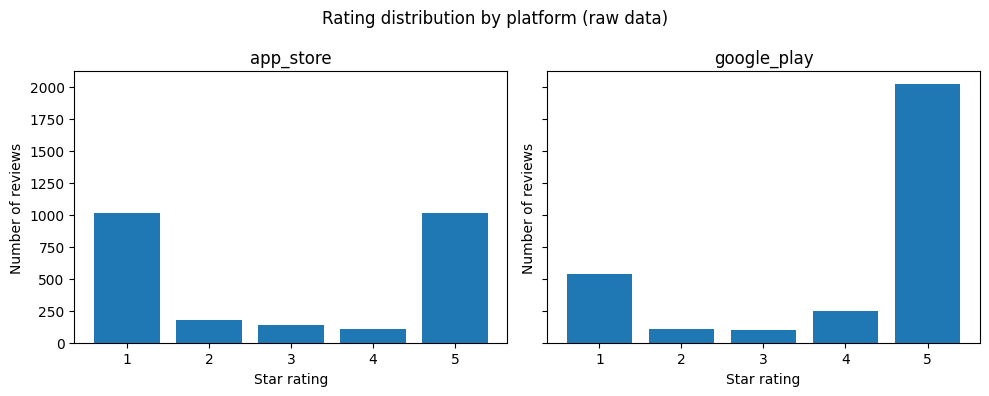

In [15]:
# Count the ratings by platform
rating_counts = (
    raw
    .groupby(["platform", "rating"])
    .size()
    .reset_index(name="n_reviews")
)

# Create one bar chart per platform
platforms = rating_counts["platform"].unique()

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(platforms),
    figsize=(10, 4),
    sharey=True
)

# If there is only one platform, make axes iterable
if len(platforms) == 1:
    axes = [axes]

for ax, platform in zip(axes, platforms):
    data = rating_counts[rating_counts["platform"] == platform]

    ax.bar(data["rating"], data["n_reviews"])
    ax.set_title(platform)
    ax.set_xlabel("Star rating")
    ax.set_ylabel("Number of reviews")

fig.suptitle("Rating distribution by platform (raw data)")
plt.tight_layout()
plt.show()

## 3. Data Preprocessing

In [16]:
df1 = raw.copy()

df1["bank"] = (
    df1["source_file"]
    .str.replace(r"__combined_us\.csv$", "", regex=True)
    .str.replace("_", " ", regex=False)
    .str.title()
)

df1["platform"] = df1["platform"].replace({
    "app_store": "iOS",
    "google_play": "Android"
})

df1.groupby(["bank", "platform"]).size().reset_index(name="n")

,bank,platform,n
0,Bank Of America,Android,600
1,Bank Of America,iOS,490
2,Chase,Android,600
3,Chase,iOS,490
4,Citi,Android,600
5,Citi,iOS,490
6,Marcus By Goldman Sachs,Android,600
7,Marcus By Goldman Sachs,iOS,490
8,Wells Fargo,Android,600
9,Wells Fargo,iOS,490


In [20]:
df2 = df1.copy()

df2["rating"] = pd.to_numeric(df2["rating"], errors="coerce")
df2["date"] = pd.to_datetime(df2["date"], errors="coerce")

rating_summary = df2["rating"].agg(
    Min="min",
    Q1=lambda x: x.quantile(0.25),
    Median="median",
    Mean="mean",
    Q3=lambda x: x.quantile(0.75),
    Max="max"
)

date_summary = df2["date"].agg(
    Min="min",
    Q1=lambda x: x.quantile(0.25),
    Median="median",
    Mean="mean",
    Q3=lambda x: x.quantile(0.75),
    Max="max"
)

print("Rating summary:")
print(rating_summary)

print("\nDate summary:")
print(date_summary)

df2.head()

Rating summary:
Min       1.000000
Q1        1.000000
Median    5.000000
Mean      3.559266
Q3        5.000000
Max       5.000000
Name: rating, dtype: float64

Date summary:
Min                2024-02-15 14:51:37-07:00
Q1       2025-09-03 14:28:22.750000128-07:00
Median             2025-11-25 17:49:48-07:00
Mean     2025-09-01 11:29:03.519183616-07:00
Q3       2025-12-12 13:57:32.750000128-07:00
Max                2025-12-28 17:23:18-07:00
Name: date, dtype: datetime64[ns, UTC-07:00]


,platform,storefront,app_id,review_id,date,user,rating,title,review,version,package,thumbsUpCount,appVersion,source_file,raw_text,raw_length_words,bank
0,iOS,us,284847138.0,13566342702,2025-12-28 13:28:49-07:00,EBP1940,1,Horrible.,I can’t load the banking app bc it requires a ...,25.04.06,NaN,NaN,NaN,bank_of_america__combined_us.csv,Horrible. I can’t load the banking app bc it r...,36,Bank Of America
1,iOS,us,284847138.0,13566341104,2025-12-28 13:28:13-07:00,papemahi,5,Enjoy,Good\r\nGood,25.12.0,NaN,NaN,NaN,bank_of_america__combined_us.csv,Enjoy Good\r\nGood,3,Bank Of America
2,iOS,us,284847138.0,13566049201,2025-12-28 11:48:52-07:00,Jiankun Li,5,Bank Of America Application Benefit,Bank Of America has an application which allow...,25.12.0,NaN,NaN,NaN,bank_of_america__combined_us.csv,Bank Of America Application Benefit Bank Of Am...,30,Bank Of America
3,iOS,us,284847138.0,13565792340,2025-12-28 10:27:09-07:00,Tom nrady,5,App,The app is easy to use for a 63-year-old woman...,25.12.0,NaN,NaN,NaN,bank_of_america__combined_us.csv,App The app is easy to use for a 63-year-old w...,43,Bank Of America
4,iOS,us,284847138.0,13564879934,2025-12-28 05:55:07-07:00,Banco América,5,Mi banco,Muy bien,25.12.0,NaN,NaN,NaN,bank_of_america__combined_us.csv,Mi banco Muy bien,4,Bank Of America


Upon checking raw text after combine title and reviews bodies, there are some reviews in different language than English, therefore, it will be removed.

In [32]:
DetectorFactory.seed = 0

def detect_language(text):
    text = str(text).strip()
    
    if not text:
        return "unknown"
    
    try:
        return detect(text)
    except:
        return "unknown"


df_lang = df2.copy()
df_lang["language"] = df_lang["raw_text"].apply(detect_language)

language_counts = (
    df_lang["language"]
    .value_counts()
    .reset_index()
)

language_counts.columns = ["language", "n"]

language_counts

,language,n
0,en,4518
1,es,201
2,so,105
3,af,99
4,ca,76
5,ro,69
6,fr,56
7,tl,45
8,da,37
9,no,34


In [33]:
df_english = df_lang[df_lang["language"] == "en"].copy()

total_reviews = len(df2)
english_reviews = len(df_english)
removed_non_english = total_reviews - english_reviews

summary_english = pd.DataFrame({
    "total_reviews": [total_reviews],
    "english_reviews": [english_reviews],
    "removed_non_english": [removed_non_english],
    "pct_removed": [
        100 * removed_non_english / total_reviews if total_reviews > 0 else 0
    ]
})

summary_english

,total_reviews,english_reviews,removed_non_english,pct_removed
0,5450,4518,932,17.100917


In [36]:
custom_words = pd.DataFrame({
    "word": ["app", "bank", "banking", "mobile", "iphone", "apple", "android", "phone"],
    "lexicon": "custom"
})

default_stop_words = pd.DataFrame({
    "word": list(ENGLISH_STOP_WORDS),
    "lexicon": "sklearn"
})

custom_stop_words = pd.concat(
    [custom_words, default_stop_words],
    ignore_index=True
).drop_duplicates(subset=["word"])

custom_stop_words.head()

,word,lexicon
0,app,custom
1,bank,custom
2,banking,custom
3,mobile,custom
4,iphone,custom


In [39]:
reviews_before_sw = df_english.copy()

reviews_before_sw["word"] = (
    reviews_before_sw["raw_text"]
    .fillna("")
    .str.lower()
    .apply(lambda x: re.findall(r"\b[a-z]+\b", x))
)

reviews_before_sw = reviews_before_sw.explode("word")
reviews_before_sw = reviews_before_sw.dropna(subset=["word"])

stop_words_set = set(custom_stop_words["word"].str.lower())

reviews_after_sw = reviews_before_sw[
    ~reviews_before_sw["word"].isin(stop_words_set)
].copy()

tokens_before = len(reviews_before_sw)
tokens_after = len(reviews_after_sw)
tokens_removed = tokens_before - tokens_after

stopword_summary = pd.DataFrame({
    "tokens_before": [tokens_before],
    "tokens_after": [tokens_after],
    "tokens_removed": [tokens_removed],
    "pct_removed": [
        100 * tokens_removed / tokens_before if tokens_before > 0 else 0
    ]
})

stopword_summary

,tokens_before,tokens_after,tokens_removed,pct_removed
0,121629,55215,66414,54.603754


In [44]:
stop_words_set = set(custom_stop_words["word"].str.lower())

removed_words = (
    reviews_before_sw[reviews_before_sw["word"].isin(stop_words_set)]
    .groupby("word")
    .size()
    .reset_index(name="n")
    .sort_values("n", ascending=False)
)

removed_words.head()

,word,n
236,to,4816
218,the,4374
117,i,4021
20,and,3179
28,app,2474


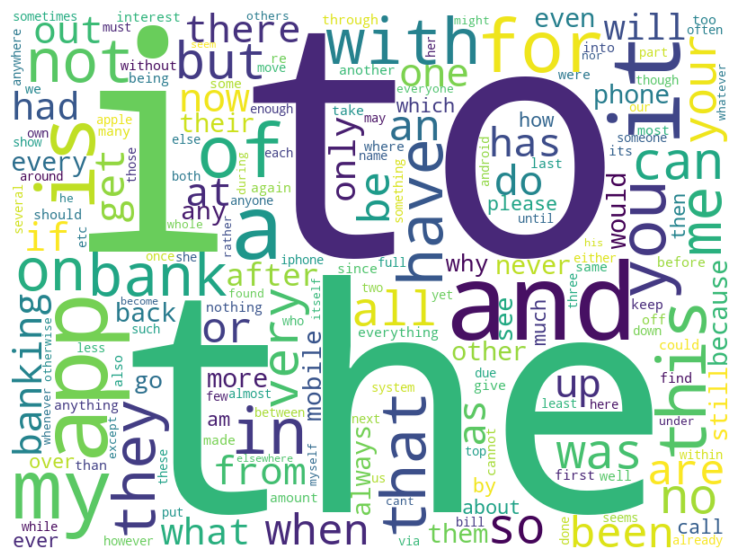

In [45]:
word_freq = dict(zip(removed_words["word"], removed_words["n"]))

wc = WordCloud(
    width=800,
    height=600,
    background_color="white",
    max_words=200
).generate_from_frequencies(word_freq)

plt.figure(figsize=(10, 7))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()